# 06 — XAI Analysis: GradCAM Visualization

GradCAM applied to the CNN models from notebook 05.

| Method | What it answers |
|---|---|
| **GradCAM** | Which spatial region of the image did the model attend to? |

## 1. Setup & Imports

In [1]:
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights, EfficientNet_B0_Weights
from PIL import Image

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IMG_ROOT     = Path('/Users/ashren/Desktop/uni/vandy/xai/project/breath_images')
MODELS_DIR   = Path('/Users/ashren/Desktop/uni/vandy/xai/project/flow-score/models')
OUT_DIR      = Path('/Users/ashren/Desktop/uni/vandy/xai/project/flow-score/notebooks/03-image-classification/xai_outputs')
OUT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print(f'Device : {DEVICE}')

Device : mps


## 2. Rebuild Models & Load Weights

In [2]:
# ── Model definitions (identical to notebook 05) ──────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features   = nn.Sequential(block(3,32), block(32,64), block(64,128), block(128,256))
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.dropout    = nn.Dropout(0.4)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.classifier(x)


def build_resnet18():
    m = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, 2)
    return m

def build_efficientnet_b0():
    m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    m.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.classifier[1].in_features, 2))
    return m


# ── Load saved weights ─────────────────────────────────────────────────────────
MODEL_REGISTRY = {
    'SimpleCNN'      : (SimpleCNN(),          'cnn_simplecnn.pt'),
    'ResNet18'       : (build_resnet18(),      'cnn_resnet18.pt'),
    'EfficientNet-B0': (build_efficientnet_b0(),'cnn_efficientnetb0.pt'),
}

loaded_models = {}
for name, (model, fname) in MODEL_REGISTRY.items():
    path = MODELS_DIR / fname
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.eval().to(DEVICE)
    loaded_models[name] = model
    print(f'Loaded {name} from {fname}')

# GradCAM target layers (last conv layer for each architecture)
GRADCAM_LAYERS = {
    'SimpleCNN'      : 'features.3.0',   # last Conv2d in block 4
    'ResNet18'       : 'layer4.1.conv2',
    'EfficientNet-B0': 'features.8.0',   # last Conv2d before classifier
}

Loaded SimpleCNN from cnn_simplecnn.pt
Loaded ResNet18 from cnn_resnet18.pt
Loaded EfficientNet-B0 from cnn_efficientnetb0.pt


## 3. Load Image Data

In [3]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def participant_from_path(p: Path) -> str:
    return p.stem.rsplit('_breath_', 1)[0]


records = []
for label, target in [('FL', 1), ('NFL', 0)]:
    for p in (IMG_ROOT / label).glob('*.png'):
        records.append({'path': p, 'label': label, 'target': target,
                        'participant': participant_from_path(p),
                        'stem': p.stem})
img_df = pd.DataFrame(records)

print(f'Total images: {len(img_df)}')

# Build viz_sample: 3 correct + 3 incorrect per class (FL and NFL)
# Run quick inference with first loaded model to identify correct/incorrect examples
_m = next(iter(loaded_models.values()))
_m.eval()

def _quick_pred(path):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return _m(x).argmax(1).item()

img_df['_pred'] = img_df['path'].apply(_quick_pred)

viz_parts = []
for target in [1, 0]:
    subset    = img_df[img_df['target'] == target]
    correct   = subset[subset['_pred'] == target]
    incorrect = subset[subset['_pred'] != target]
    n_c = min(3, len(correct))
    n_w = min(3, len(incorrect))
    picked = pd.concat([
        correct.sample(n_c, random_state=SEED),
        incorrect.sample(n_w, random_state=SEED),
    ])
    # pad to 6 if one pool is too small
    if len(picked) < 6:
        remaining = subset.drop(picked.index)
        pad = remaining.sample(min(6 - len(picked), len(remaining)), random_state=SEED)
        picked = pd.concat([picked, pad])
    viz_parts.append(picked)

viz_sample = pd.concat(viz_parts).reset_index(drop=True)
for target, lbl in [(1, 'FL'), (0, 'NFL')]:
    s = viz_sample[viz_sample['target'] == target]
    n_corr = (s['_pred'] == target).sum()
    print(f'Viz {lbl}: {n_corr} correct, {len(s)-n_corr} incorrect')

Total images: 7007
Viz FL: 3 correct, 3 incorrect
Viz NFL: 3 correct, 3 incorrect


## 4. Helper Utilities

In [4]:
def load_tensor(path: Path, device=DEVICE) -> torch.Tensor:
    """Load a single image as a normalised (1, 3, H, W) tensor."""
    img = Image.open(path).convert('RGB')
    return transform(img).unsqueeze(0).to(device)


def tensor_to_display(t: torch.Tensor) -> np.ndarray:
    """Convert a (1,3,H,W) or (3,H,W) normalised tensor back to a displayable (H,W) grayscale array."""
    t = t.squeeze().cpu()
    if t.dim() == 3:
        # Undo normalisation and average channels
        mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
        std  = torch.tensor(IMAGENET_STD).view(3,1,1)
        t = t * std + mean
        t = t.mean(0)
    return t.numpy().clip(0, 1)


print('Utilities defined.')

Utilities defined.


## 5. GradCAM

Registers forward/backward hooks on the last conv layer. The heatmap shows which spatial regions of the waveform image the model used most when making its prediction.

In [5]:
class GradCAM:
    def __init__(self, model: nn.Module, layer_name: str):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._hooks      = []

        # Find target layer by dotted name
        layer = model
        for part in layer_name.split('.'):
            layer = getattr(layer, part)

        self._hooks.append(
            layer.register_forward_hook(lambda m, i, o: setattr(self, 'activations', o))
        )
        self._hooks.append(
            layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0]))
        )

    def __call__(self, x: torch.Tensor, target_class: int) -> np.ndarray:
        self.model.zero_grad()
        logits = self.model(x)
        logits[0, target_class].backward()

        # Global average pool gradients over spatial dims
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE),
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam -= cam.min()
        cam /= cam.max() + 1e-8
        return cam

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()


print('GradCAM defined.')

GradCAM defined.



SimpleCNN
  FL correct: 3, NFL correct: 3, incorrect (2 FL→NFL + 1 NFL→FL)


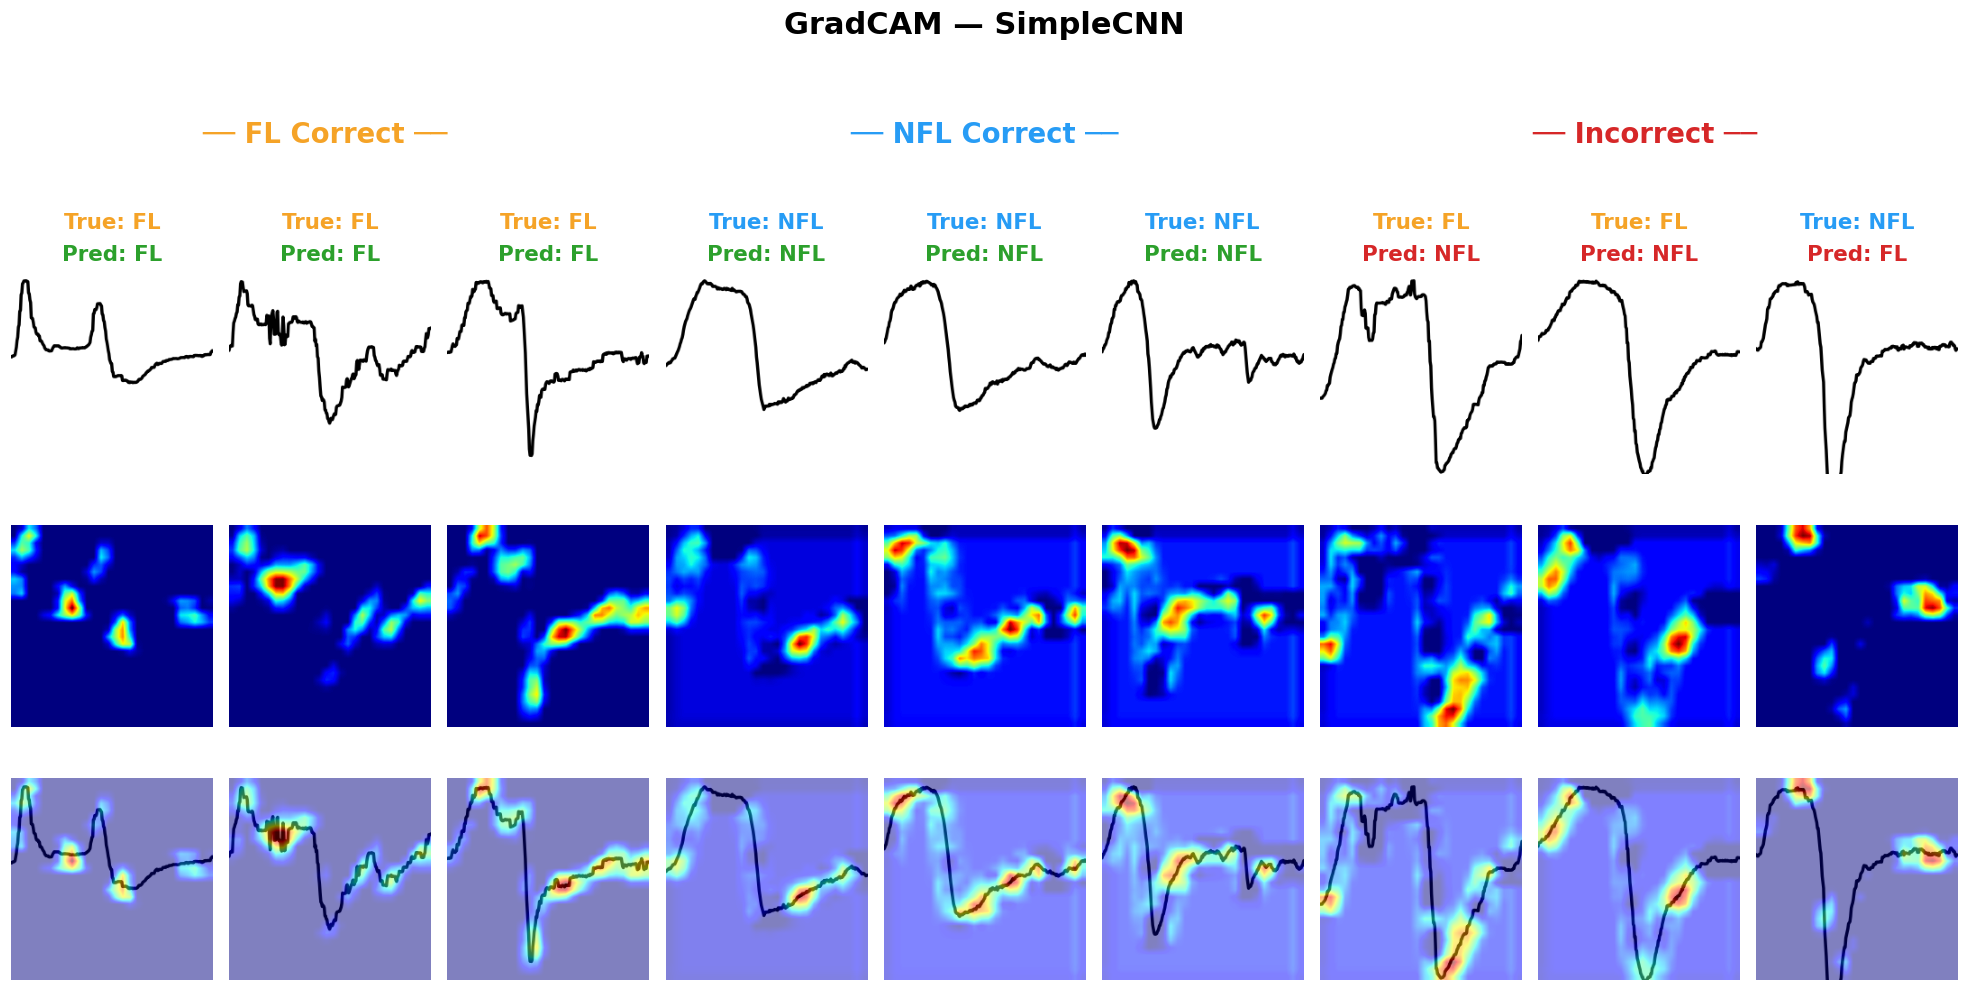

Saved: gradcam_grouped_simplecnn.png

ResNet18
  FL correct: 3, NFL correct: 3, incorrect (2 FL→NFL + 1 NFL→FL)


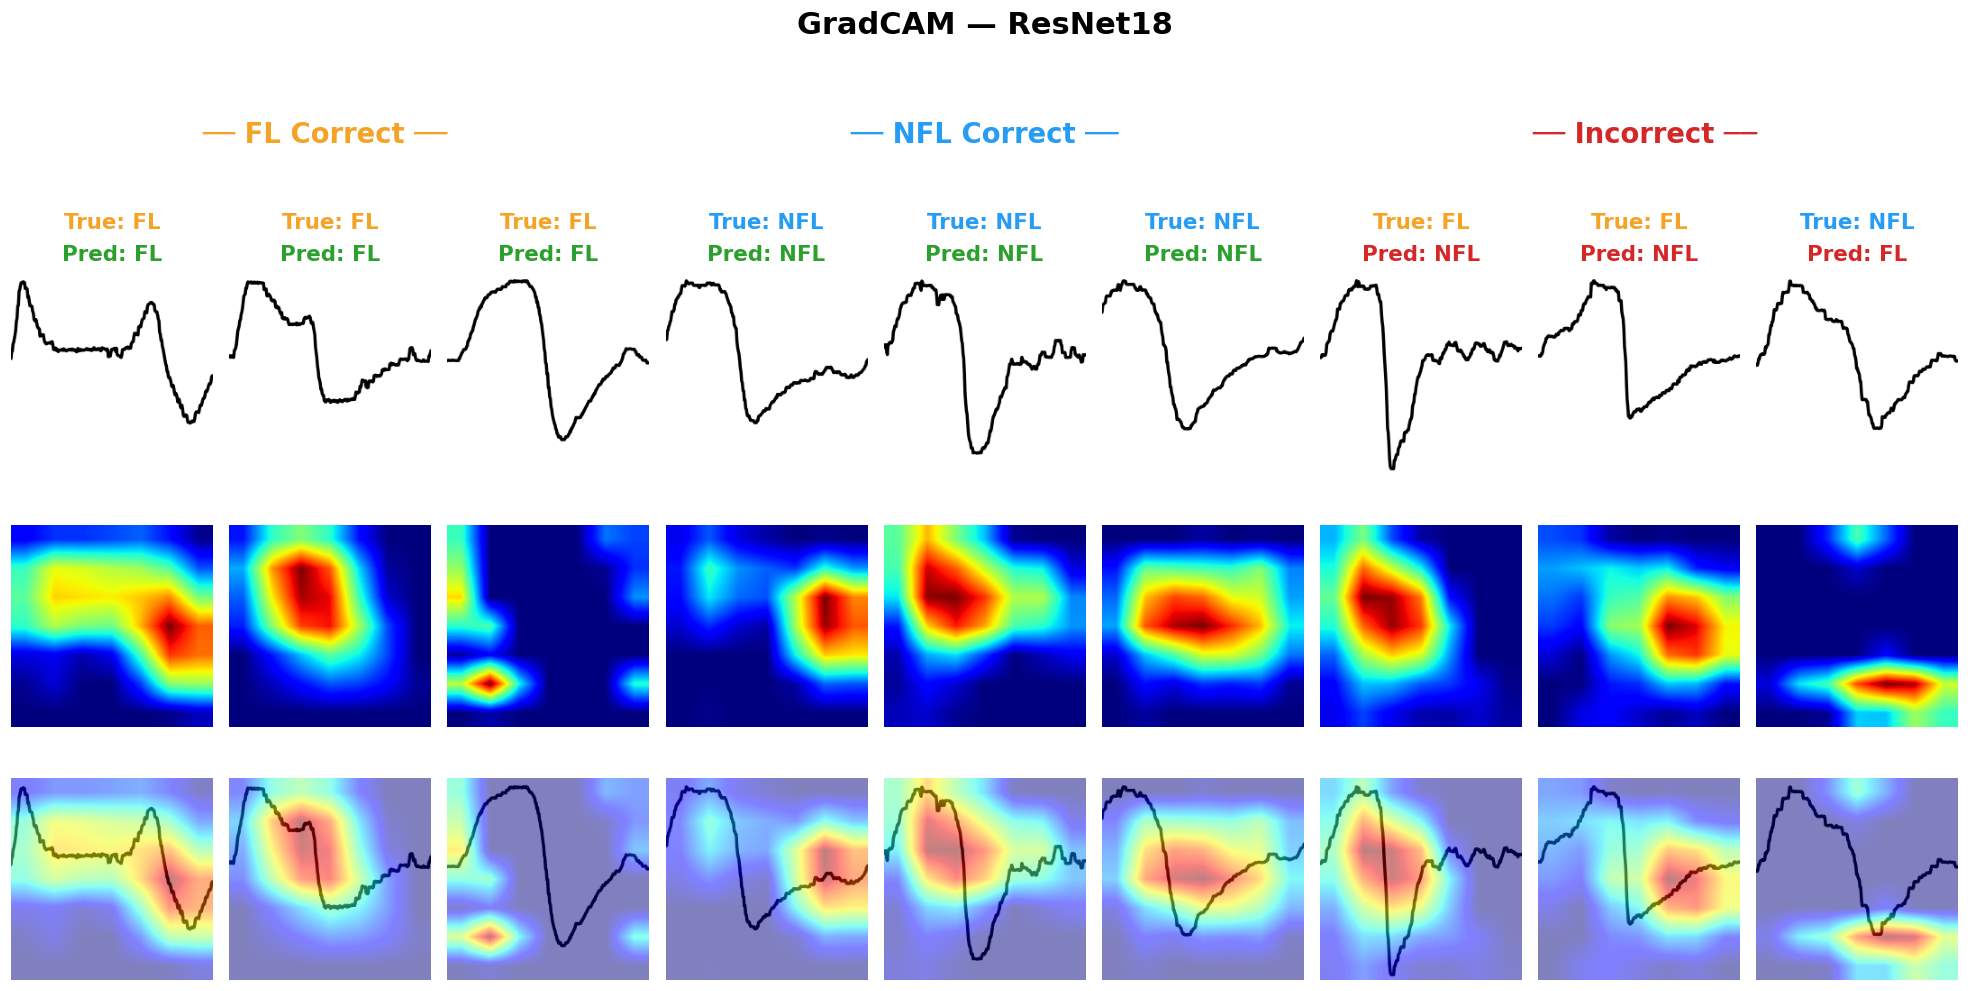

Saved: gradcam_grouped_resnet18.png

EfficientNet-B0
  FL correct: 3, NFL correct: 3, incorrect (2 FL→NFL + 1 NFL→FL)


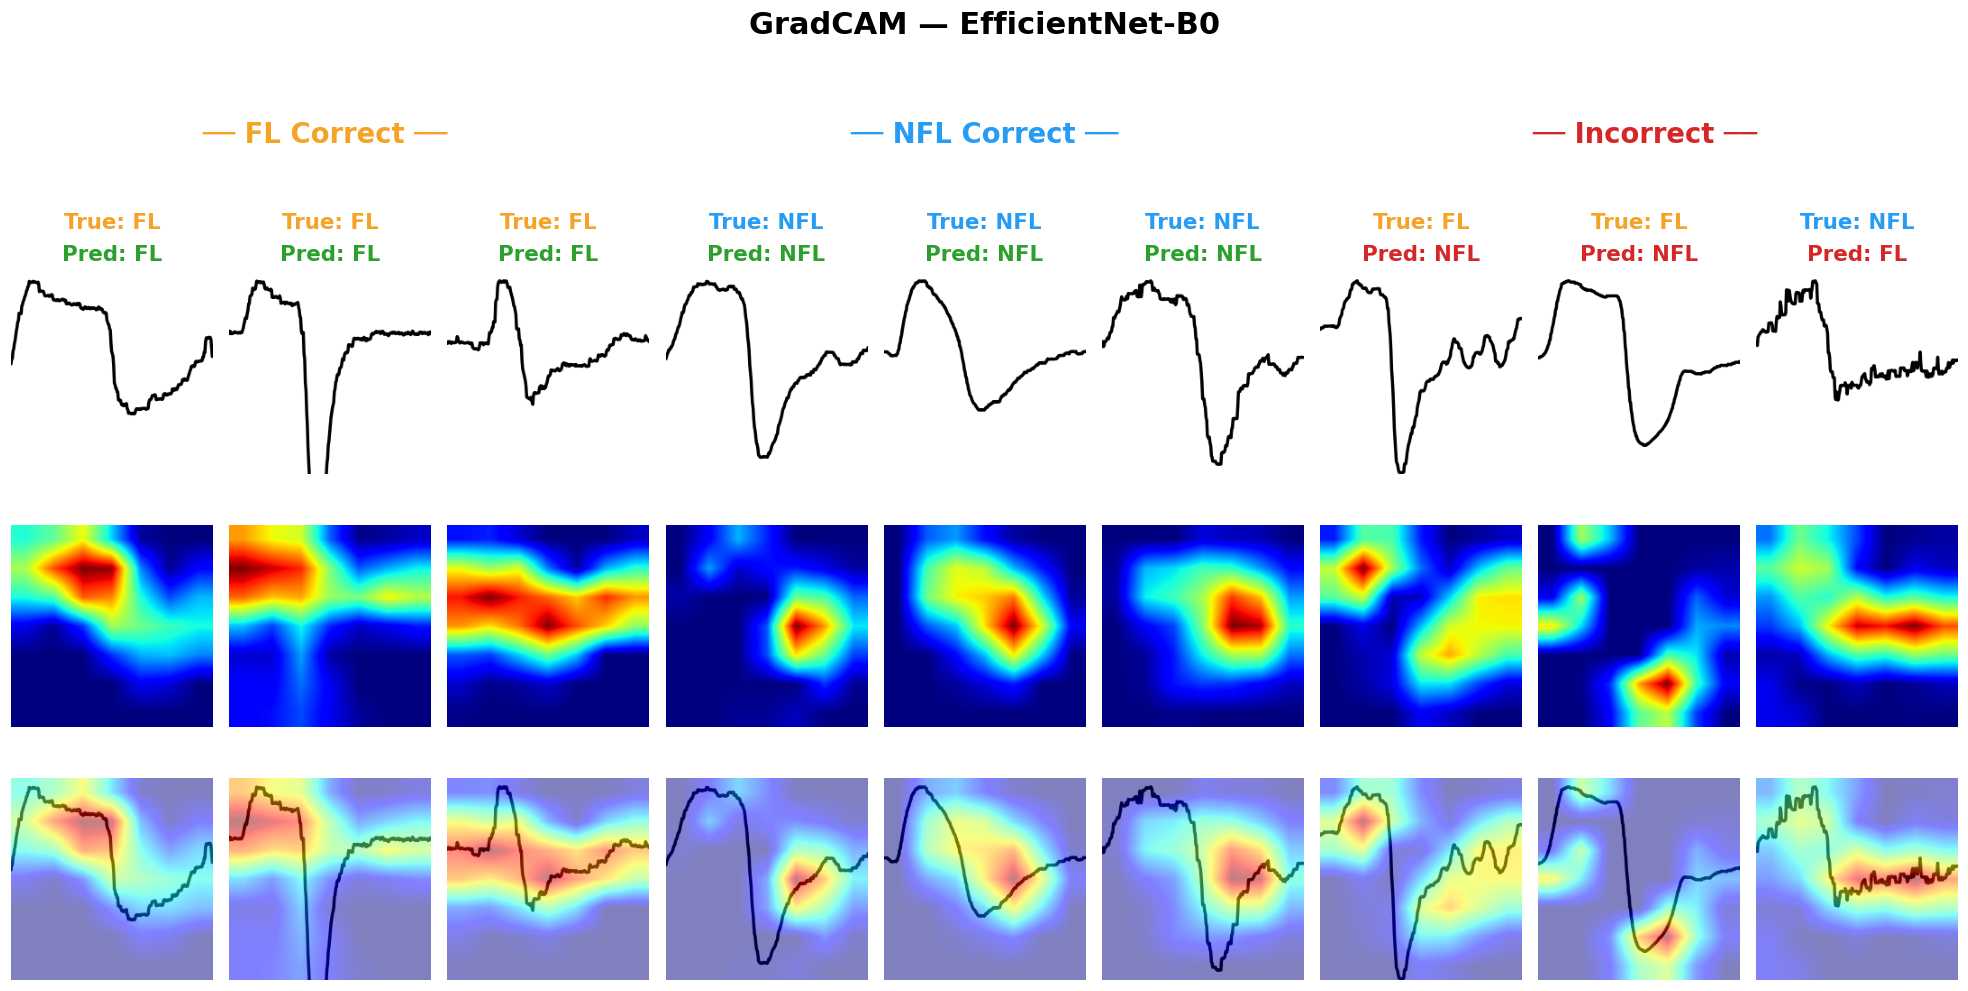

Saved: gradcam_grouped_efficientnetb0.png


In [19]:
# ── GradCAM: 3 FL correct | 3 NFL correct | 3 incorrect ─────────────────────
def get_grouped_viz_sample(model, n=3):
    model.eval()
    preds = []
    for _, row in img_df.iterrows():
        x = load_tensor(row["path"])
        with torch.no_grad():
            preds.append(model(x).argmax(1).item())
    tmp = img_df.copy()
    tmp["_pred"] = preds

    fl_correct  = tmp[(tmp["target"] == 1) & (tmp["_pred"] == 1)].sample(n, random_state=SEED)
    nfl_correct = tmp[(tmp["target"] == 0) & (tmp["_pred"] == 0)].sample(n, random_state=SEED)

    # Force a mix: ~2 from one error type, ~1 from the other
    fl_as_nfl = tmp[(tmp["target"] == 1) & (tmp["_pred"] == 0)]
    nfl_as_fl = tmp[(tmp["target"] == 0) & (tmp["_pred"] == 1)]
    n_fl  = min(2, len(fl_as_nfl))
    n_nfl = n - n_fl
    if n_nfl > len(nfl_as_fl):
        n_fl  = n - len(nfl_as_fl)
        n_nfl = len(nfl_as_fl)
    incorrect = pd.concat([
        fl_as_nfl.sample(n_fl,  random_state=SEED) if n_fl  > 0 else pd.DataFrame(),
        nfl_as_fl.sample(n_nfl, random_state=SEED) if n_nfl > 0 else pd.DataFrame(),
    ])

    sample = pd.concat([fl_correct, nfl_correct, incorrect]).reset_index(drop=True)
    print(f"  FL correct: {n}, NFL correct: {n}, incorrect ({n_fl} FL→NFL + {n_nfl} NFL→FL)")
    return sample


for model_name, model in loaded_models.items():
    print(f"\n{model_name}")
    model_sample = get_grouped_viz_sample(model, n=3)
    gcam = GradCAM(model, GRADCAM_LAYERS[model_name])

    n_cols = len(model_sample)   # 9 = 3 FL correct + 3 NFL correct + 3 incorrect
    fig, axes = plt.subplots(3, n_cols, figsize=(18, 10))

    for col, (_, row) in enumerate(model_sample.iterrows()):
        x      = load_tensor(row["path"])
        img_np = tensor_to_display(x)

        with torch.enable_grad():
            logits     = model(x)
            pred_class = logits.argmax(1).item()
            cam        = gcam(x, pred_class)

        true_label = "FL"  if row["target"] == 1 else "NFL"
        pred_label = "FL"  if pred_class    == 1 else "NFL"
        is_correct = pred_class == row["target"]

        true_color = "#F5A327" if row["target"] == 1 else "#279CF5"
        pred_color = "#2ca02c" if is_correct else "#d62728"

        ax0 = axes[0, col]
        ax0.imshow(img_np, cmap="gray"); ax0.axis("off")
        ax0.text(0.5, 1.20, f"True: {true_label}", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=14, fontweight="bold", color=true_color)
        ax0.text(0.5, 1.04, f"Pred: {pred_label}", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=14, fontweight="bold", color=pred_color)

        axes[1, col].imshow(cam, cmap="jet"); axes[1, col].axis("off")

        axes[2, col].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        axes[2, col].imshow(cam, cmap="jet", alpha=0.5); axes[2, col].axis("off")

    for ax, label in zip(axes[:, 0], ["Original", "GradCAM", "Overlay"]):
        ax.set_ylabel(label, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.80])
    fig.text(1/6, 0.84, "── FL Correct ──",  ha="center", fontsize=18, fontweight="bold", color="#F5A327")
    fig.text(3/6, 0.84, "── NFL Correct ──", ha="center", fontsize=18, fontweight="bold", color="#279CF5")
    fig.text(5/6, 0.84, "── Incorrect ──",   ha="center", fontsize=18, fontweight="bold", color="#d62728")

    plt.suptitle(f"GradCAM — {model_name}", fontweight="bold", y=0.96, fontsize=20)
    fname = f"gradcam_grouped_{model_name.lower().replace('-','').replace(' ','_')}.png"
    plt.savefig(OUT_DIR / fname, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

    gcam.remove_hooks()